In [33]:
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve,
    validation_curve
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    precision_recall_curve,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss
)

# Load Dataset

df = pd.read_csv(
    "/content/drive/MyDrive/Heart Disease Cleveland UCI/heart_cleveland_upload.csv"
)

# Dataset Overview

print(f"Dataset Shape: {df.shape}")
display(df.head())

# Features and Target

X = df.drop("condition", axis=1)
y = df["condition"]

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining Set Shape: {X_train.shape}")
print(f"Testing Set Shape : {X_test.shape}")

Dataset Shape: (297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0



Training Set Shape: (237, 13)
Testing Set Shape : (60, 13)


In [34]:
start_train = time.time()

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train, y_train)

train_time = time.time() - start_train

In [35]:
start_test = time.time()

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

test_time = time.time() - start_test

In [36]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_prob)
balanced_accuracy=balanced_accuracy_score(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
loss=log_loss(y_test,y_prob)
cv_scores = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=10,
    scoring="accuracy"
)

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

In [37]:
print("=" * 50)
print("Logistic Regression Performance")
print("=" * 50)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC AUC            : {roc_auc:.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy:.4f}")
print(f"MCC                : {mcc:.4f}")
print(f"Cohen Kappa        : {kappa:.4f}")
print(f"Log Loss           : {loss:.4f}")

print(f"\nCV Mean Accuracy   : {cv_mean:.4f}")
print(f"CV Std             : {cv_std:.4f}")

print(f"\nTraining Time      : {train_time:.4f} sec")
print(f"Prediction Time    : {test_time:.4f} sec")

Logistic Regression Performance
Accuracy           : 0.9167
Precision          : 1.0000
Recall             : 0.8214
F1 Score           : 0.9020
ROC AUC            : 0.9531
Balanced Accuracy  : 0.9107
MCC                : 0.8429
Cohen Kappa        : 0.8307
Log Loss           : 0.2843

CV Mean Accuracy   : 0.8067
CV Std             : 0.0961

Training Time      : 0.0767 sec
Prediction Time    : 0.0076 sec


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60



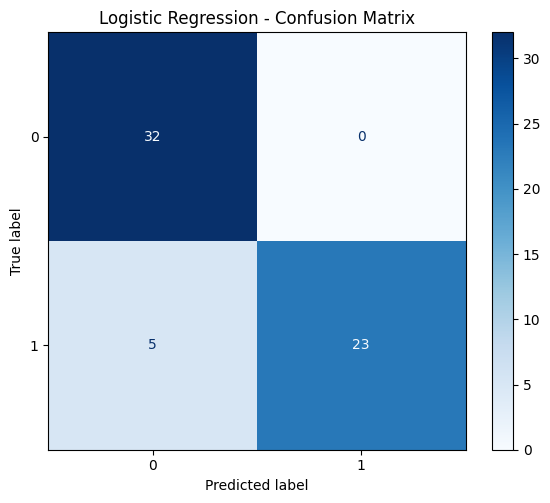

In [39]:
#Confusion Matrix
fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=ax
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

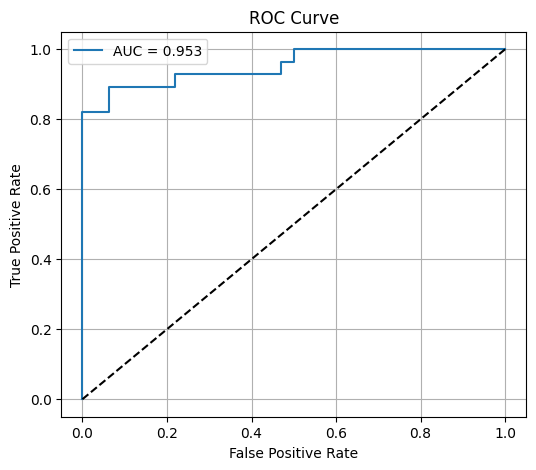

In [46]:
#ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.grid(True)

plt.show()

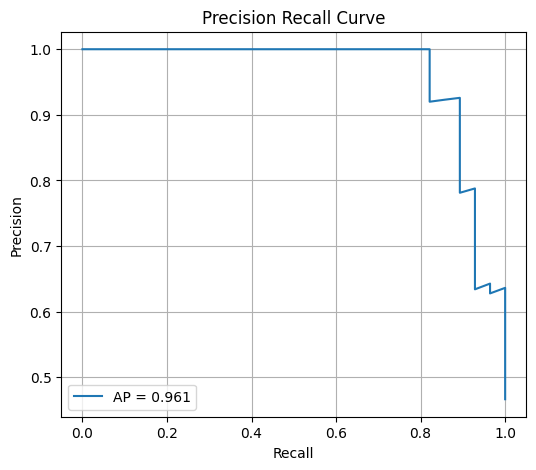

In [41]:
#Precision Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"AP = {ap:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

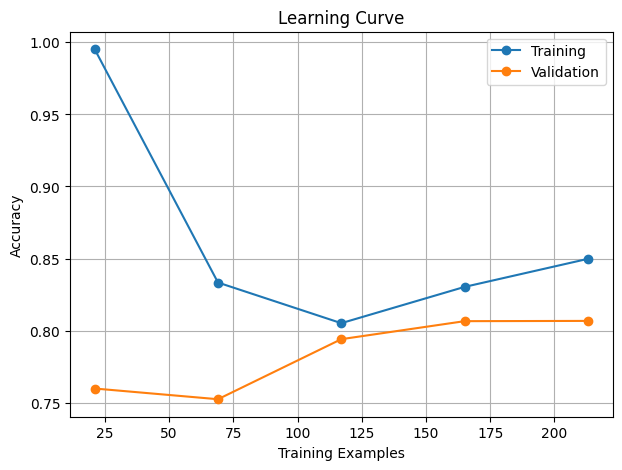

In [42]:
#Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    log_reg,
    X_train,
    y_train,
    cv=10,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.plot(train_sizes, train_mean, marker="o", label="Training")

plt.plot(train_sizes, test_mean, marker="o", label="Validation")

plt.xlabel("Training Examples")
plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.grid(True)

plt.show()

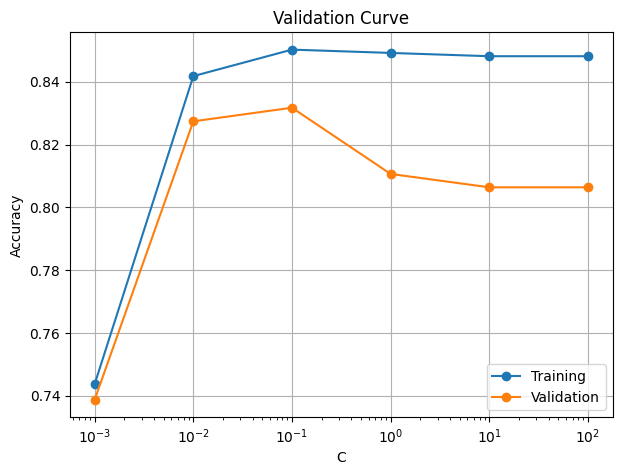

In [32]:
param_range = [0.001, 0.01, 0.1, 1, 10, 100]

train_scores, test_scores = validation_curve(
    LogisticRegression(max_iter=1000),
    X_train,
    y_train,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.semilogx(param_range, train_mean, marker='o', label="Training")

plt.semilogx(param_range, test_mean, marker='o', label="Validation")

plt.xlabel("C")

plt.ylabel("Accuracy")

plt.title("Validation Curve")

plt.legend()

plt.grid(True)

plt.show()